In [1]:
# Import packages
import os
from pathlib import Path

os.chdir(Path.cwd().parent)
project_dir = Path("/home/mcaskey/10XvParse/")
analysis_name = "Analysis_6"

import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
hto_data = ad.read_h5ad(project_dir / f"Data/{analysis_name}/10x_hashtags/kb_python/all_out/counts_unfiltered/adata.h5ad")
adata = ad.read_h5ad(project_dir / f"Data/{analysis_name}/10x/kb_python/all_out/counts_unfiltered/adata.h5ad")

# remove 0 columns from hto_data
hto_data.var["n_counts"] = hto_data.X.sum(axis=0).A1
hto_data = hto_data[:, hto_data.var["n_counts"] > 0].copy()


In [3]:
hto_data.obs["n_counts"] = hto_data.X.sum(axis=1)
adata.obs["n_hto_counts"] = hto_data.obs["n_counts"]
adata.obs["n_counts"] = adata.X.sum(axis=1)

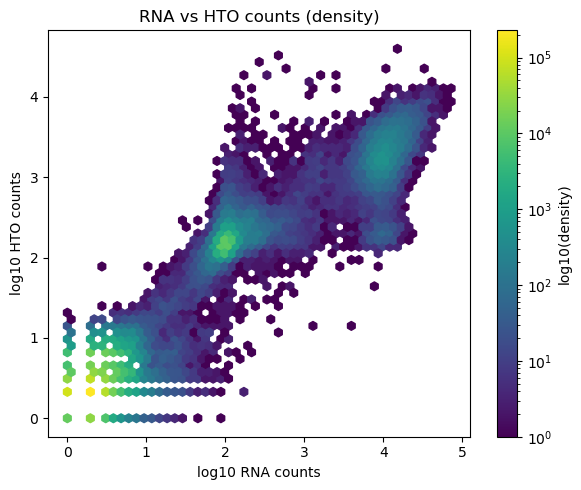

In [4]:
x = np.log10(adata.obs['n_counts'] + 1)
y = np.log10(adata.obs['n_hto_counts'] + 1)

plt.figure(figsize=(6, 5))
hb = plt.hexbin(x, y, gridsize=50, bins='log')
plt.colorbar(hb, label='log10(density)')

plt.xlabel('log10 RNA counts')
plt.ylabel('log10 HTO counts')
plt.title('RNA vs HTO counts (density)')

plt.tight_layout()
plt.show()

In [5]:
common = adata.obs_names.intersection(hto_data.obs_names)
adata = adata[common].copy()
hto_data = hto_data[common].copy()

# Put hashtag counts into adata.obs
hto_df = pd.DataFrame(
    hto_data.X.toarray() if hasattr(hto_data.X, "toarray") else hto_data.X,
    index=hto_data.obs_names,
    columns=hto_data.var_names
)


In [6]:

adata.obs = adata.obs.join(hto_df)

# Run HashSolo using the hashtag column names
sc.external.pp.hashsolo(adata, cell_hashing_columns=list(hto_data.var_names))

Please cite HashSolo paper:
https://www.cell.com/cell-systems/fulltext/S2405-4712(20)30195-2


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/scanpy/external/pp/_hashsolo.py:98: RuntimeWarning: divide by zero encountered in scalar divide
  lam = 1 / np.var(data) if len(data) > 1 else lam_o
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/scanpy/external/pp/_hashsolo.py:101: RuntimeWarning: invalid value encountered in scalar divide
  (np.mean(data) * n * lam + mu_o * lam_o) / lam_n if len(data) > 0 else mu_o


<BarContainer object of 22 artists>

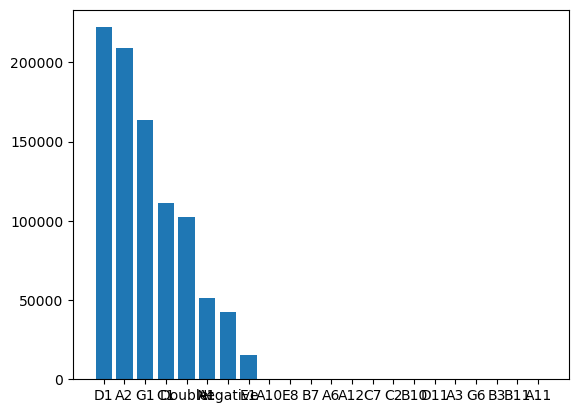

In [10]:
demux_pd = adata.obs[["Classification"]]
plt.bar(demux_pd["Classification"].value_counts().index, demux_pd["Classification"].value_counts().values)

In [12]:
hto_config_dir = project_dir / f"Configs/{analysis_name}/10x"
Path(project_dir / hto_config_dir).mkdir(exist_ok=True)
demux_pd.to_csv(hto_config_dir / "hto_demultiplexed.csv")